

 Import Essential Libraries



In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import random
import networkx as nx
import matplotlib.pyplot as plt

Loading Data (Gene Expression File)

In [2]:
data = pd.read_csv('100_1_knockdowns.tsv', sep='\t')

In [3]:
data

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G91,G92,G93,G94,G95,G96,G97,G98,G99,G100
0,0.096999,0.227366,0.431403,0.350564,0.614166,0.037278,0.608806,0.402018,0.024301,0.534258,...,0.520794,0.348856,0.648020,0.460299,0.422432,0.640388,0.238413,0.651695,0.536379,0.640927
1,0.140357,0.116043,0.498218,0.286252,0.708196,0.037699,0.645638,0.447637,0.031831,0.444297,...,0.609565,0.446938,0.655062,0.370700,0.522416,0.594598,0.209250,0.590257,0.561454,0.548147
2,0.075864,0.215462,0.245413,0.263025,0.695526,0.057789,0.659812,0.423609,0.005288,0.504874,...,0.720783,0.311021,0.637153,0.415287,0.405801,0.523387,0.278230,0.551977,0.588909,0.571148
3,0.081394,0.193503,0.561137,0.133510,0.657569,0.053319,0.534083,0.415155,0.010994,0.408166,...,0.670272,0.498790,0.549552,0.368304,0.392148,0.643276,0.351833,0.681212,0.554729,0.498315
4,0.146972,0.019467,0.520126,0.200362,0.289476,0.146236,0.522055,0.325684,0.009394,0.345423,...,0.656710,0.488208,0.530460,0.392846,0.365890,0.637134,0.240219,0.672030,0.520975,0.643914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.136612,0.218060,0.410735,0.309124,0.623771,0.057232,0.758860,0.430003,0.002582,0.463476,...,0.702393,0.469732,0.639036,0.406945,0.464915,0.352919,0.368327,0.645155,0.459091,0.582123
96,0.181643,0.254944,0.502419,0.445739,0.604940,0.070491,0.521393,0.399001,0.007459,0.497652,...,0.678336,0.351175,0.651234,0.448695,0.483983,0.610818,0.143644,0.564751,0.593970,0.798616
97,0.086596,0.248284,0.417322,0.325038,0.642527,0.050735,0.553526,0.410098,0.044201,0.425274,...,0.585763,0.481626,0.624413,0.323185,0.538718,0.611075,0.256141,0.455464,0.264548,0.557122
98,0.154695,0.240120,0.572381,0.305699,0.612217,0.034965,0.692328,0.418754,0.026105,0.553897,...,0.551415,0.451893,0.601532,0.403350,0.589157,0.586016,0.301276,0.662294,0.233315,0.577539


Using K-means Clustering for each Column(Gene) to Discretize the Data

In [4]:
def discretize_data(data):
    discretized_data = pd.DataFrame()
    kmeans = KMeans(n_clusters=2, random_state=0)
    for col in data.columns:
        labels = kmeans.fit_predict(data[[col]])
        discretized_data[col] = labels
    return discretized_data

In [5]:
discretized_data = discretize_data(data)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

In [6]:
discretized_data

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G91,G92,G93,G94,G95,G96,G97,G98,G99,G100
0,1,0,0,1,0,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,1
1,1,0,1,1,1,0,1,1,0,0,...,1,1,1,1,1,0,0,0,1,0
2,1,0,0,1,1,1,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
3,1,0,1,1,1,1,0,0,0,0,...,0,1,0,1,0,1,1,1,1,0
4,1,0,1,1,0,1,0,0,0,0,...,0,1,0,1,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,0,0,1,0,1,1,1,0,1,...,0,1,0,1,1,0,1,1,0,0
96,0,1,1,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
97,1,1,0,1,1,1,0,0,1,0,...,1,1,0,1,1,0,0,0,0,0
98,1,0,1,1,0,0,1,0,0,1,...,1,1,0,1,1,0,1,1,0,0


Calculate Conditional Probability Tables (Confugurations)

In [7]:
def calculate_cpt(data, model):
    # an empty dictionary for CPTs
    cpts = {}

    # For each gene
    for i in range(model.shape[0]):
        # indices of the gene's parents
        parents = np.where(model[i] == 1)[0]

        # count each config
        counts = {}

        # For each data point
        for j in range(data.shape[0]):
            # state of the gene and its parents
            gene_state = data.iloc[j, i]
            parent_state = tuple(data.iloc[j, parents])

            # add the count for this config
            state_count = counts.get(parent_state, {0: 0, 1: 0})
            state_count[gene_state] += 1
            counts[parent_state] = state_count

        # probabilities for each config
        probabilities = {}

        # For each parent state
        for parent_state in counts:
            # the total count for this parent state
            total_count = sum(counts[parent_state].values())

            # the probabilities for each gene state
            gene_probabilities = {gene_state: count / total_count for gene_state, count in counts[parent_state].items()}

            # Add the probabilities to the CPT
            probabilities[parent_state] = gene_probabilities

        # Add the CPT to the dictionary of CPTs
        cpts[i] = probabilities

    return cpts

Calculate Log-Likelihood (How much each model (graph structure/adjacency matrix) is probable given the data (gene expression dataset)

In [8]:
def calculate_log_likelihood(data, model):
    # the CPTs for the model
    cpts = calculate_cpt(data, model)

    # Initialize the log-likelihood
    log_likelihood = 0

    # For each data point
    for i in range(data.shape[0]):
        # For each gene
        for j in range(data.shape[1]):
            # state of the gene and its parents
            gene_state = data.iloc[i, j]
            parent_state = tuple(data.iloc[i, np.where(model[j] == 1)[0]])

            # Add the log of the conditional probability of the gene state given the parent state to the log-likelihood
            log_likelihood += np.log(cpts[j][parent_state][gene_state])

    return log_likelihood


Test the function

How to propose a new model given the current model using add, delete or reverse edges)

In [9]:
def propose_new_model(current_model):

    new_model = current_model.copy()

    # add, remove, or reverse randomly
    operation = random.choice(['add', 'remove', 'reverse'])


    if operation == 'add':
        # Choose two unconnected nodes
        available_nodes = np.argwhere(new_model == 0)
        if len(available_nodes) > 0:
            i, j = random.choice(available_nodes)
            # Add the edge
            new_model[i, j] = 1

    elif operation == 'remove':
        # where are edges?
        existing_edges = np.argwhere(new_model == 1)
        if len(existing_edges) > 0:
            i, j = random.choice(existing_edges)
            # Remove the edge
            new_model[i, j] = 0

    elif operation == 'reverse':
        # where are edges?
        existing_edges = np.argwhere(new_model == 1)
        if len(existing_edges) > 0:
            i, j = random.choice(existing_edges)
            # Reverse the edge
            new_model[i, j] = 0
            new_model[j, i] = 1

    return new_model

Check if the graph is cyclic (to be rejected later)

In [10]:
def is_cyclic(model):
    graph = nx.DiGraph(model)
    cycles = list(nx.simple_cycles(graph))
    return len(cycles) > 0

Metropolis Hastings Algorithm using acceptance probability

In [11]:
def metropolis_hastings(data, iterations):
    # Number of nodes
    n = data.shape[1]

    # initialization
    current_model = np.zeros((n, n))

    models = []
    log_likelihoods = []


    for _ in range(iterations):
        # Propose
        proposed_model = propose_new_model(current_model)

        # If cyclic, reject
        if is_cyclic(proposed_model):
            continue

        # the log-likelihoods of the data given the current and proposed models
        current_log_likelihood = calculate_log_likelihood(data, current_model)
        proposed_log_likelihood = calculate_log_likelihood(data, proposed_model)

        # the acceptance probability formulation
        acceptance_probability = min(1,np.exp(proposed_log_likelihood - current_log_likelihood))

        # Accept or reject
        if random.random() < acceptance_probability:
            current_model = proposed_model
            models.append(current_model)
            log_likelihoods.append(current_log_likelihood)

    return models, log_likelihoods

Run Metropolis-Hastings three times, guess burn-in period based on the plot, and calculate an average burn-in period

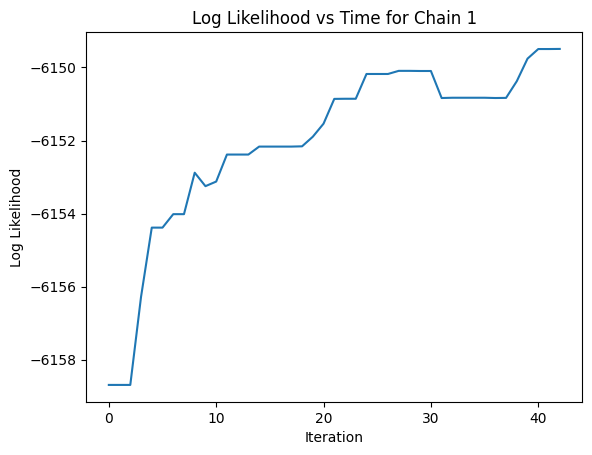

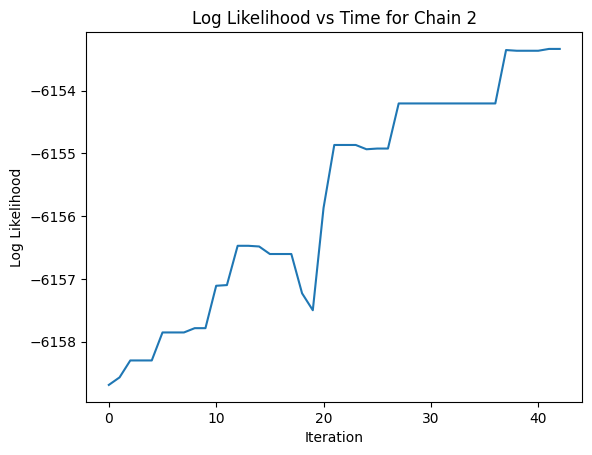

Enter your guess for the burn-in period: 40
Average Burn-in Period:  40


In [12]:
num_chains = 2
burn_in_guesses = []

for i in range(num_chains):
    np.random.seed(i)  # Use a different seed for each chain
    models, log_likelihoods = metropolis_hastings(discretized_data, 50)

    plt.plot(log_likelihoods)
    plt.xlabel('Iteration')
    plt.ylabel('Log Likelihood')
    plt.title('Log Likelihood vs Time for Chain {}'.format(i+1))
    plt.show()

    # my burn-in guesses
    burn_in_guess = int(input("Enter your guess for the burn-in period: "))
    burn_in_guesses.append(burn_in_guess)

# the average burn-in period
average_burn_in = int(np.mean(burn_in_guesses))
print("Average Burn-in Period: ", average_burn_in)


Averaging the models after average burn-in period, and using a threshold to make the model binary (to find out where the edges are)

In [13]:
def average_models(models, burn_in):
    # Ignore the burn-in
    models_after_burn_in = models[burn_in:]

    # mean of models
    mean_of_models = np.mean(models_after_burn_in, axis=0)

    # Threshold to get a binary matrix
    averaged_model = (mean_of_models > 0.5).astype(int)

    return averaged_model


In [14]:
averaged_model = average_models(models,average_burn_in)


In [15]:
averaged_model

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

Comparing the True Model (gold file) and the average model (which was predicted)

In [16]:
true_model = pd.read_csv('100_01_gold.txt', index_col=0).values

In [17]:
true_model

array([[0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [18]:
# TP, TN, FP, FN
TP = np.sum((averaged_model == 1) & (true_model == 1))
TN = np.sum((averaged_model == 0) & (true_model == 0))
FP = np.sum((averaged_model == 1) & (true_model == 0))
FN = np.sum((averaged_model == 0) & (true_model == 1))

In [19]:
TP, TN, FP, FN

(0, 9817, 8, 175)

Calculate Evaluation Metrics

In [20]:
# Precision
if TP + FP != 0:
    precision = TP / (TP + FP)
else:
    precision = np.nan


# Recall
recall = TP / (TP + FN)

# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# F1 Score
f1_score = 2 * precision * recall / (precision + recall)

<ipython-input-20-b8241d7b6a68>:15: RuntimeWarning: invalid value encountered in double_scalars
  f1_score = 2 * precision * recall / (precision + recall)


In [21]:
precision, recall, accuracy, f1_score

(0.0, 0.0, 0.9817, nan)

How do models look like?

In [22]:
def plot_graph(model, title):
    G = nx.DiGraph()

    # Convert matrix to list of edges
    n = model.shape[0]
    edges = np.argwhere(model == 1)
    edges = [(edges[i, 0], edges[i, 1]) for i in range(edges.shape[0])]

    G.add_edges_from(edges)

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)
    nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

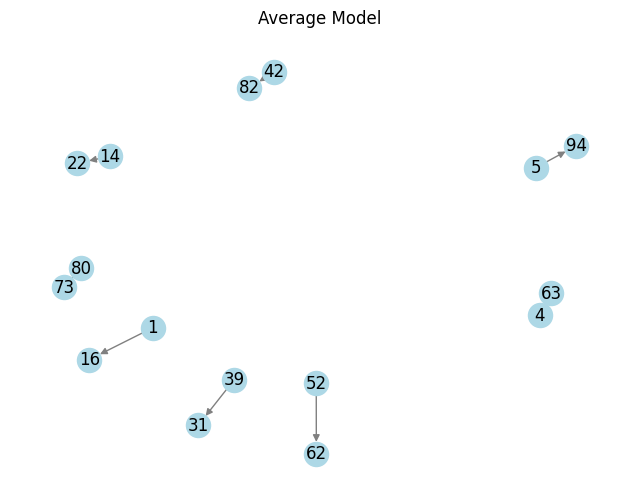

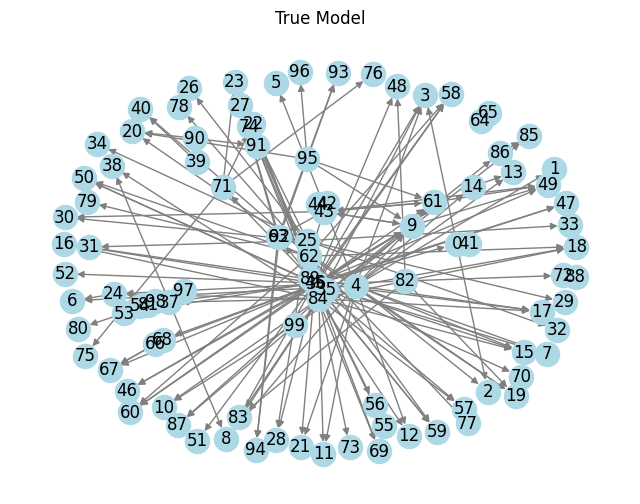

In [23]:
plot_graph(averaged_model, 'Average Model')
plot_graph(true_model, 'True Model')